In [264]:
from sklearn.datasets import make_classification

In [265]:
X,y = make_classification(
    n_samples=500,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_classes=2,
    random_state=0
)

In [266]:
import numpy as np
import pandas as pd

X = np.transpose(X)

In [267]:
dictionary = {
    "f1":X[0],
    "f2":X[1],
    "f3":X[2],
    "f4":X[3],
    "f5":X[4],
    "f6":X[5],
    "label":y
}

In [268]:
df = pd.DataFrame(
    dictionary
)

In [269]:
df.head()

,f1,f2,f3,f4,f5,f6,label
0,0.028395,-0.567997,0.438095,1.197280,-0.282920,-0.548010,1
1,2.915094,0.032431,1.902095,-1.223337,-1.678530,-2.053231,0
2,5.232660,0.189196,3.266558,-1.957618,-2.749741,-4.068053,0
3,1.308229,2.420556,1.064108,1.351062,-0.641219,-2.209203,1
4,1.146818,-0.021692,1.415019,1.145238,-2.096182,-0.456854,1


In [270]:
df.describe()

,f1,f2,f3,f4,f5,f6,label
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.685600,-0.007350,-0.008037,-0.030422,-0.425288,-0.532704,0.500000
std,1.493524,1.022867,1.370286,1.434135,1.471652,1.444831,0.500501
min,-3.135209,-2.623976,-3.512415,-4.952792,-4.688107,-4.082893,0.000000
25%,-0.421753,-0.710676,-0.997470,-1.125702,-1.475183,-1.460867,0.000000
50%,0.645003,0.000852,-0.220552,0.183964,-0.342092,-0.587707,0.500000
75%,1.692037,0.652540,1.006579,1.126208,0.650782,0.330266,1.000000
max,5.264347,3.505474,3.976290,3.467290,4.356168,4.129384,1.000000


In [271]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      500 non-null    float64
 1   f2      500 non-null    float64
 2   f3      500 non-null    float64
 3   f4      500 non-null    float64
 4   f5      500 non-null    float64
 5   f6      500 non-null    float64
 6   label   500 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 27.5 KB


In [272]:
from sklearn.model_selection import train_test_split


X_train,X_test,y_train,y_test = train_test_split(df[["f1","f2","f3","f4","f5","f6"]],df["label"] , test_size=0.2 , random_state=0)

In [273]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [274]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [275]:
from sklearn.svm import SVC



svm_rbf = SVC(kernel="rbf" ,  C = 1)
svm_poly = SVC(kernel="poly" ,  C = 1)
svm_linear = SVC(kernel="linear" ,  C = 1)

In [276]:

svm_rbf.fit(X_train,y_train)
svm_linear.fit(X_train,y_train)
svm_poly.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [277]:
y_test.shape

(100,)

In [278]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

def get_metrics(svm):

    y_pred = svm.predict(X_test)

    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    cm = confusion_matrix(y_test,y_pred)


    print("Accuracy:",accuracy)
    print("Precision:",precision)
    print("Recall:",recall)
    print("F1:",f1)
    # print("CM:",cm)

    return accuracy,precision,recall,f1,cm

In [279]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

print("\n" ,'='*10)
print("RBF METRICS : ")
print('='*10 , end="\n\n")
accuracy_rbf,precision_rbf,recall_rbf,f1_rbf,cm_rbf = get_metrics(svm_rbf)

print("\n" ,'='*10)
print("LINEAR METRICS : ")
print('='*10 , end="\n\n")

accuracy_linear,precision_linear,recall_linear,f1_linear,cm_linear = get_metrics(svm_linear)

print("\n" ,'='*10)
print("POLY METRICS : ")
print('='*10 , end="\n\n")
accuracy_poly,precision_poly,recall_poly,f1_poly,cm_poly = get_metrics(svm_poly)




RBF METRICS : 

Accuracy: 0.85
Precision: 0.8723404255319149
Recall: 0.82
F1: 0.845360824742268

LINEAR METRICS : 

Accuracy: 0.7
Precision: 0.7
Recall: 0.7
F1: 0.7

POLY METRICS : 

Accuracy: 0.78
Precision: 0.868421052631579
Recall: 0.66
F1: 0.75


In [280]:
import seaborn as sns

def plot_heatmap(cm):
    sns.heatmap(cm , annot=True)


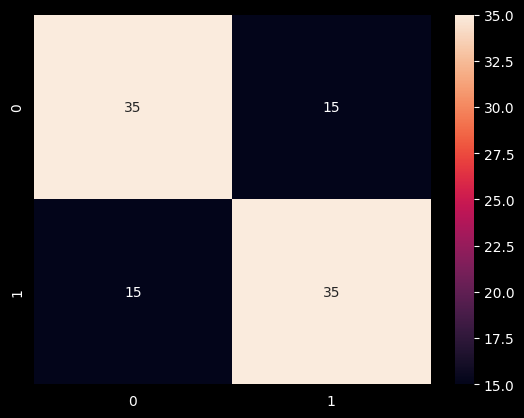

In [281]:
plot_heatmap(cm_linear)

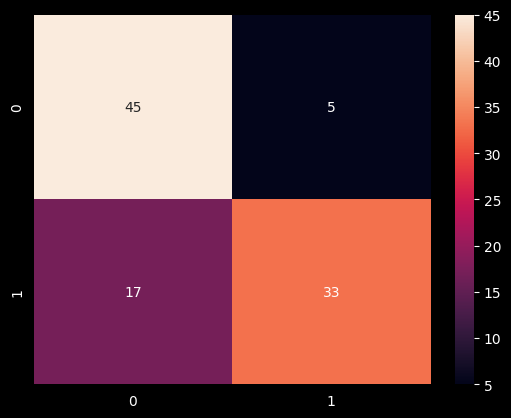

In [282]:
plot_heatmap(cm_poly)

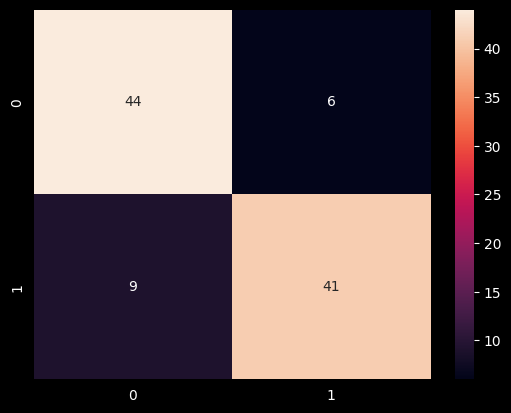

In [283]:
plot_heatmap(cm_rbf)

In [284]:
comparison = pd.DataFrame({
    "Kernel": ["Linear","Poly","RBF"],
    "Accuracy": [accuracy_linear,accuracy_poly,accuracy_rbf],
    "Precision":[precision_linear,precision_poly,precision_rbf],
    "Recall" : [recall_linear,recall_poly,recall_rbf],
    "F1": [f1_linear,f1_poly,f1_rbf],
})

In [285]:
comparison

,Kernel,Accuracy,Precision,Recall,F1
0,Linear,0.70,0.700000,0.70,0.700000
1,Poly,0.78,0.868421,0.66,0.750000
2,RBF,0.85,0.872340,0.82,0.845361


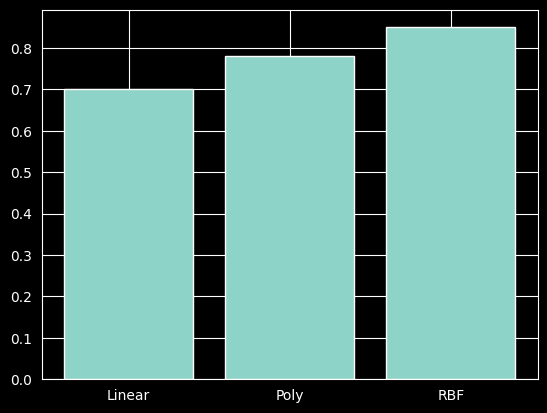

In [286]:
import matplotlib.pyplot as plt


plt.bar(comparison["Kernel"] , comparison["Accuracy"])
plt.show()